# ClusterMind Chaos Arena — Training Notebook (TRL / Unsloth-compatible)

**This notebook is judge-runnable end-to-end on a free Colab T4.**

Two paths exist; the script picks automatically based on what's installed:

| Path | When | What runs |
|---|---|---|
| **LLM / LoRA (preferred)** | `transformers + peft` available (Colab default) | Qwen2.5-0.5B-Instruct base, **frozen weights**, LoRA r=8, SFT cross-entropy → online RL on live env |
| **Policy-net plumbing (fallback)** | Bare torch only (laptop CPU) | Tiny MLP over engineered features, BC + REINFORCE — proves the loop with no GPU |

> **Disclosure (PRD §26):** We freeze the base model and update only LoRA adapter weights during SFT and GRPO/PPO/REINFORCE training.

Estimated runtime: ~12 min quick mode, ~40 min `--full` on a T4.

## 1 — Install dependencies

In [101]:
!pip install -q openenv-core pydantic numpy matplotlib pandas plotly networkx PyYAML
!pip install -q transformers accelerate peft trl sentencepiece einops datasets bitsandbytes
!pip install -q gradio
# wandb is optional; uncomment to use:
# !pip install -q wandb

## 2 — Clone the repo

In [102]:
import os
REPO = '/content/clustermind-chaos-arena'
if not os.path.isdir(REPO):
    !git clone --depth=1 https://github.com/Kabeer-Scaler/META_RL_HACKATHON_CLUSTERMIND $REPO || echo 'replace URL with your fork before running'
%cd $REPO
import sys; sys.path.insert(0, REPO)
print('repo ready at', REPO)

/content/clustermind-chaos-arena
repo ready at /content/clustermind-chaos-arena


## 3 — Imports

In [103]:
import os, sys
REPO = '/content/clustermind-chaos-arena'
REPO_URL = 'https://github.com/Kabeer-Scaler/META_RL_HACKATHON_CLUSTERMIND.git'
if os.path.isdir(REPO) and not os.path.isdir(os.path.join(REPO, 'clustermind')):
    !rm -rf $REPO
if not os.path.isdir(REPO):
    !git clone --depth=1 $REPO_URL $REPO
else:
    # Repo already present — pull latest so re-runs always use the newest code.
    !git -C $REPO pull --ff-only
%cd $REPO
sys.path.insert(0, REPO)
assert os.path.isdir(os.path.join(REPO, 'clustermind')), 'clone failed'
print('repo ready')

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 859 bytes | 15.00 KiB/s, done.
From https://github.com/Kabeer-Scaler/META_RL_HACKATHON_CLUSTERMIND
   f3521e7..c7294a7  main       -> origin/main
Updating 6579f0f..c7294a7
error: Your local changes to the following files would be overwritten by merge:
	results/loss_curve.png
	results/reward_curve.png
Please commit your changes or stash them before you merge.
Aborting
/content/clustermind-chaos-arena
repo ready


In [104]:
import sys
import os
import importlib

REPO = '/content/clustermind-chaos-arena'

# Force refresh of sys.path
if REPO not in sys.path:
    sys.path.insert(0, REPO)

# Invalidate caches to force Python to see new files
importlib.invalidate_caches()

try:
    from clustermind import ClusterMindChaosEnv, ClusterMindEnv
    from clustermind.baselines import ALL_BASELINES, RandomAgent, GreedyThroughputAgent, ThermalAwareHeuristicAgent
    from clustermind.agents import LLMJsonAgent, TransformersBackend
    from clustermind.scenarios import SCENARIO_NAMES
    print('Successfully imported clustermind!')
    print('Baselines:', list(ALL_BASELINES.keys()))
    print('Scenarios:', SCENARIO_NAMES)
except ImportError as e:
    print(f'Import still failed: {e}')
    print(f'Checking {REPO}/clustermind contents: {os.listdir(os.path.join(REPO, "clustermind")) if os.path.exists(os.path.join(REPO, "clustermind")) else "Directory not found"}')

Successfully imported clustermind!
Baselines: ['RandomAgent', 'GreedyThroughputAgent', 'ConservativeAutoscalerAgent', 'ThermalAwareHeuristicAgent', 'BackfillAgent']
Scenarios: ['demand_spike', 'cooling_failure', 'hidden_degradation', 'cascading_failure', 'energy_squeeze', 'vip_job_arrival', 'triple_crisis', 'chaos_arena']


## 4 — Smoke tests (17 checks must pass)

In [105]:
!python scripts/run_smoke_tests.py

[PASS] env.reset returns valid observation
[PASS] env.step returns quad
[PASS] env.state returns hidden state
[PASS] episode terminates at max_steps
[PASS] seeded determinism (job IDs)
[PASS] all 8 scenarios reset+step
[PASS] all 5 baselines run an episode
[PASS] reward clipped to [-1, 1]
[PASS] invalid action does not crash
[PASS] thermal dynamics run
[PASS] cooling action accepted
[PASS] guardrail evaluation runs
[PASS] flight recorder captures steps
[PASS] failure chain explanation produced
[PASS] chaos respects per-episode budget
[PASS] chaos disabled at low levels
[PASS] observation is JSON serialisable

Smoke tests: 17/17 passed


## 5 — Baseline quick sweep
Runs all 5 heuristics on all 8 scenarios at curriculum levels 3/4/5. Result is the comparison ground truth that the trained agent has to beat.

In [106]:
!python scripts/run_baselines.py --episodes 5 --levels 3 4 5 --output results/baseline_metrics.json

RandomAgent                      reward=  7.26 crit= 16.6% outage=2.97 cascade=1.03 gv_rate=0.38 inv_rate=0.00
GreedyThroughputAgent            reward=  9.83 crit= 91.6% outage=3.54 cascade=1.40 gv_rate=0.17 inv_rate=0.00
ConservativeAutoscalerAgent      reward=  8.64 crit= 90.8% outage=3.59 cascade=1.40 gv_rate=0.17 inv_rate=0.00
ThermalAwareHeuristicAgent       reward=  9.81 crit= 90.1% outage=3.54 cascade=1.41 gv_rate=0.15 inv_rate=0.00
BackfillAgent                    reward= 10.05 crit= 90.9% outage=3.52 cascade=1.35 gv_rate=0.16 inv_rate=0.00

Saved results/baseline_metrics.json


In [107]:
import json
with open('results/baseline_metrics.json') as f:
    payload = json.load(f)
print(f"{'agent':32s} {'reward':>7s} {'crit%':>6s} {'outage':>7s} {'cascade':>8s} {'gv_rate':>8s}")
print('-' * 75)
for name, blob in payload['agents'].items():
    s = blob['summary']
    print(f"{name:32s} {s['avg_reward']:7.2f} {s['critical_completion_rate']*100:5.1f}%"
          f" {s['avg_outage_count']:7.2f} {s['avg_cascade_count']:8.2f} {s['avg_guardrail_violation_rate']:8.2f}")

agent                             reward  crit%  outage  cascade  gv_rate
---------------------------------------------------------------------------
RandomAgent                         7.26  16.6%    2.97     1.03     0.38
GreedyThroughputAgent               9.83  91.6%    3.54     1.40     0.17
ConservativeAutoscalerAgent         8.64  90.8%    3.59     1.40     0.17
ThermalAwareHeuristicAgent          9.81  90.1%    3.54     1.41     0.15
BackfillAgent                      10.05  90.9%    3.52     1.35     0.16


## 6 — Collect heuristic rollouts (SFT seed data)
Filtered for: valid action AND no guardrail violation AND positive reward (PRD §26.1).

In [108]:
from scripts.train_trl import collect_heuristic_rollouts
rollouts = collect_heuristic_rollouts(n_episodes=16, seed_base=7000)
print(f'Collected {len(rollouts)} filtered transitions for SFT')
by_action = {}
for r in rollouts:
    by_action[r.abstract_action.value] = by_action.get(r.abstract_action.value, 0) + 1
print('action distribution:', by_action)

Collected 278 filtered transitions for SFT
action distribution: {'ALLOCATE_JOB': 64, 'NO_OP': 196, 'DELAY_JOB': 14, 'INCREASE_COOLING': 4}


## 7 — Train: frozen base + LoRA, SFT → GRPO/PPO/REINFORCE

The script picks the strongest RL algorithm available:
- `--rl-algo grpo` — episode-level group-relative advantage with K=2 trajectories per seed
- `--rl-algo ppo` — REINFORCE + KL penalty against the frozen reference policy
- `--rl-algo reinforce` — moving-baseline REINFORCE (universal fallback)
- `--rl-algo auto` — picks GRPO if `trl` is installed, else REINFORCE

Use `--quick` for ~10-min Colab runs, `--full` for ~40-min runs.

In [117]:
import os
REPO = '/content/clustermind-chaos-arena'
# Always pull latest fixes before running training
!git -C $REPO pull --ff-only
# Load HF token from Colab secrets for faster HF Hub downloads (optional)
try:
    from google.colab import userdata
    _tok = userdata.get('HF_TOKEN')
    if _tok: os.environ['HF_TOKEN'] = _tok; print('HF_TOKEN loaded')
except Exception:
    pass
!python scripts/train_trl.py \
    --mode auto \
    --base-model Qwen/Qwen2.5-0.5B-Instruct \
    --rl-algo auto \
    --grpo-group-size 2 \
    --sft-episodes 16 \
    --rl-episodes 24 \
    --eval-episodes 6 \
    --seed 42 \
    --quick

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 3), reused 6 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.00 KiB | 26.00 KiB/s, done.
From https://github.com/Kabeer-Scaler/META_RL_HACKATHON_CLUSTERMIND
   c7294a7..791ad6b  main       -> origin/main
Updating 6579f0f..791ad6b
error: Your local changes to the following files would be overwritten by merge:
	results/baseline_metrics.json
	results/cascade_count_comparison.png
	results/chaos_survival_score.png
	results/cluster_health_curve.png
	results/critical_job_completion.png
	results/evaluation_metrics.json
	results/guardrail_violations.png
	results/loss_curve.png
	results/outage_comparison.png
	results/reward_curve.png
	results/training_logs.jsonl
Please commit your changes or stash them before you merge.
Aborting
HF_TOKEN loaded
[mode] llm
[LLM] loading base model: Qwen/Qwen2.5-0.5B-Instruct
`torch_dtype` is 

In [110]:
import json
with open('results/trained_results.json') as f:
    tr = json.load(f)
print(f"schema:    {tr.get('schema')}")
print(f"rl_algo:   {tr.get('rl_algo')}  ({tr.get('rl_algo_note', '')})")
print(f"frozen_base={tr.get('frozen_base')}  lora_only={tr.get('lora_only')}")
if 'trainable_params' in tr:
    pct = tr['trainable_params'] / max(1, tr['total_params']) * 100
    print(f"trainable: {tr['trainable_params']:,} / {tr['total_params']:,} ({pct:.2f}%)")
if tr.get('rl_rewards'):
    print(f"RL reward: first 5={[round(r,2) for r in tr['rl_rewards'][:5]]}  last 5={[round(r,2) for r in tr['rl_rewards'][-5:]]}")

schema:    clustermind.training.policy_net.v1
rl_algo:   reinforce  (policy-net path uses REINFORCE with moving baseline (no LLM stack present))
frozen_base=False  lora_only=False
RL reward: first 5=[13.31, 11.66, 8.94, 11.53, 8.36]  last 5=[11.53, 8.36, 10.61, 12.84, 11.8]


## 8 — Evaluate: 5 baselines + Base LLM + SFT LoRA + RL LoRA
Pass `--rl-adapter` if Step 7 produced one (LLM path); the evaluator will load it on top of the same base model.

In [111]:
import os
ADAPTER = 'results/adapters/clustermind_lora'
have_lora = os.path.isdir(ADAPTER)
print(f'LoRA adapter present: {have_lora}')
if have_lora:
    !python scripts/evaluate.py \
        --episodes 5 --levels 3 4 5 \
        --include-llm transformers \
        --base-model Qwen/Qwen2.5-0.5B-Instruct \
        --rl-adapter $ADAPTER \
        --output results/evaluation_metrics.json
else:
    print('Falling back to baseline-only evaluation (Step 7 ran the policy-net plumbing path).')
    !python scripts/evaluate.py --episodes 5 --levels 3 4 5 --output results/evaluation_metrics.json

LoRA adapter present: False
Falling back to baseline-only evaluation (Step 7 ran the policy-net plumbing path).
RandomAgent                      reward=  7.62 crit= 17.6% outage=3.01 cascade=1.01 grade=F
GreedyThroughputAgent            reward=  9.93 crit= 92.8% outage=3.53 cascade=1.35 grade=C
ConservativeAutoscalerAgent      reward=  8.58 crit= 93.0% outage=3.52 cascade=1.27 grade=C
ThermalAwareHeuristicAgent       reward=  9.76 crit= 93.5% outage=3.45 cascade=1.27 grade=C
BackfillAgent                    reward=  9.81 crit= 93.8% outage=3.44 cascade=1.33 grade=C

Saved results/evaluation_metrics.json


## 9 — Generate the eight required plots from real logs

In [112]:
!python scripts/generate_plots.py

wrote  /content/clustermind-chaos-arena/results/reward_curve.png
wrote  /content/clustermind-chaos-arena/results/loss_curve.png
wrote  /content/clustermind-chaos-arena/results/outage_comparison.png
wrote  /content/clustermind-chaos-arena/results/cascade_count_comparison.png
wrote  /content/clustermind-chaos-arena/results/critical_job_completion.png
wrote  /content/clustermind-chaos-arena/results/guardrail_violations.png
wrote  /content/clustermind-chaos-arena/results/chaos_survival_score.png
wrote  /content/clustermind-chaos-arena/results/cluster_health_curve.png


**reward_curve.png** — Per-episode RL reward across live env rollouts.

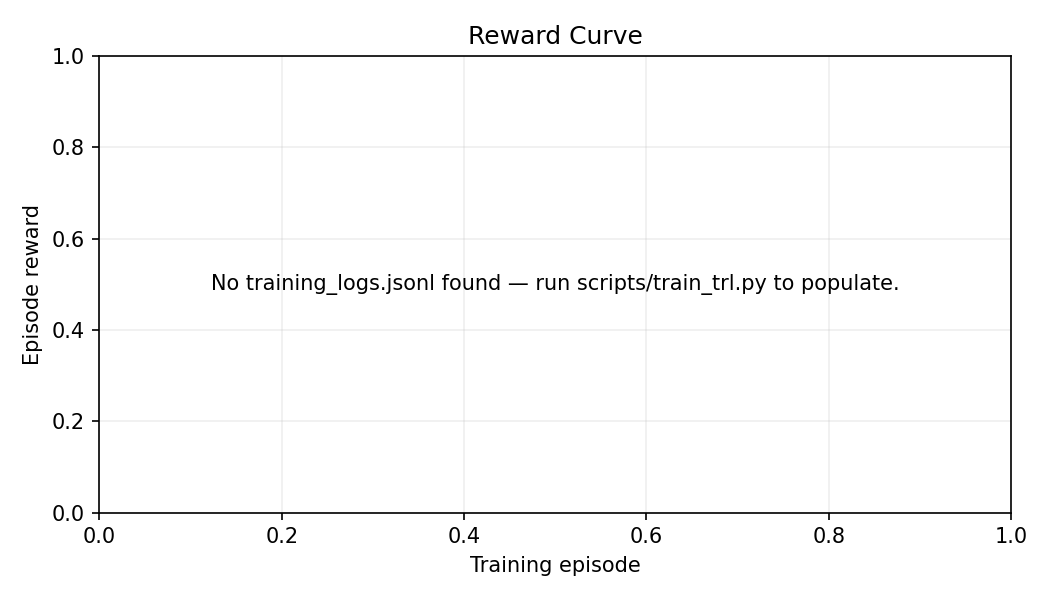

**loss_curve.png** — SFT cross-entropy + RL policy loss.

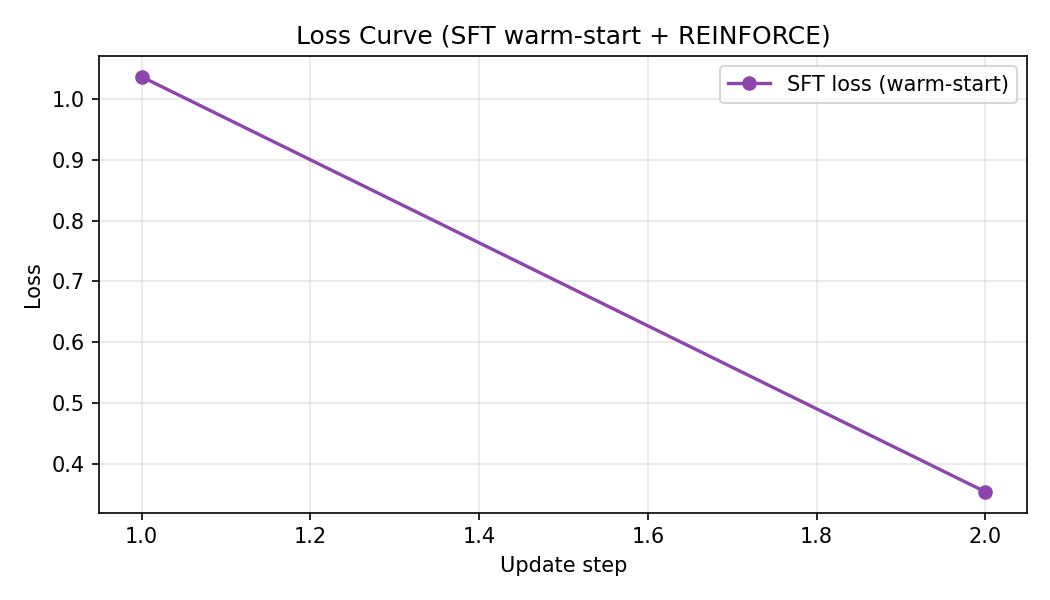

**outage_comparison.png** — Average outages per episode by agent.

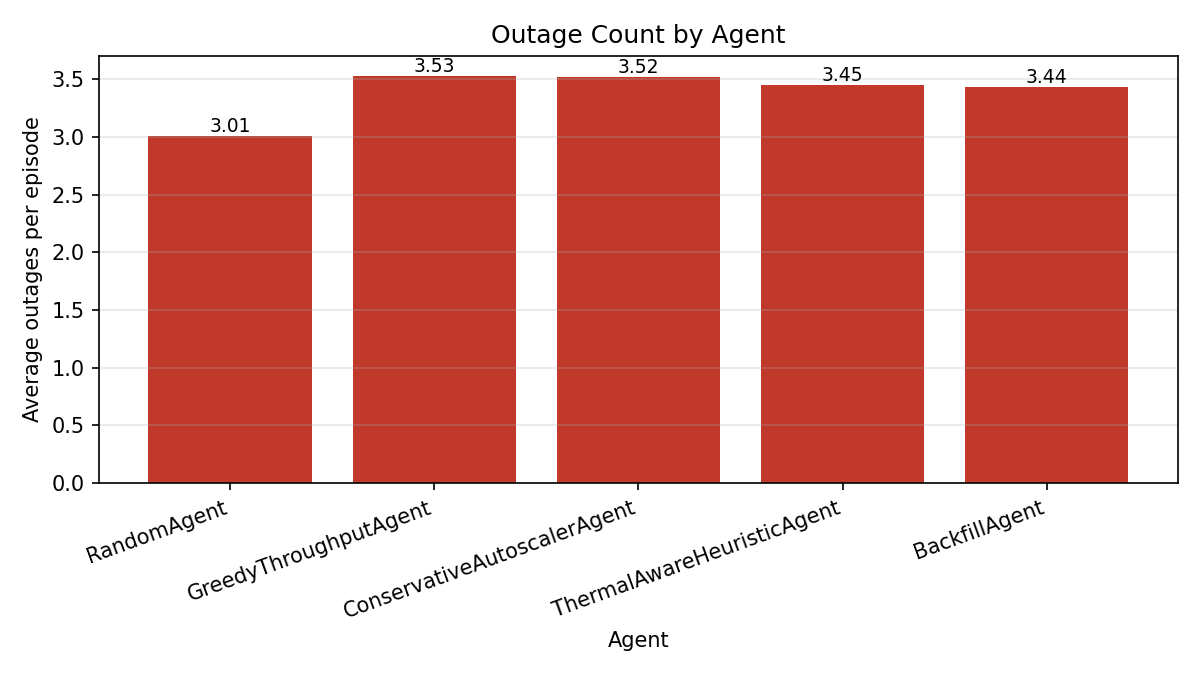

**cascade_count_comparison.png** — Linked-failure cascades per agent.

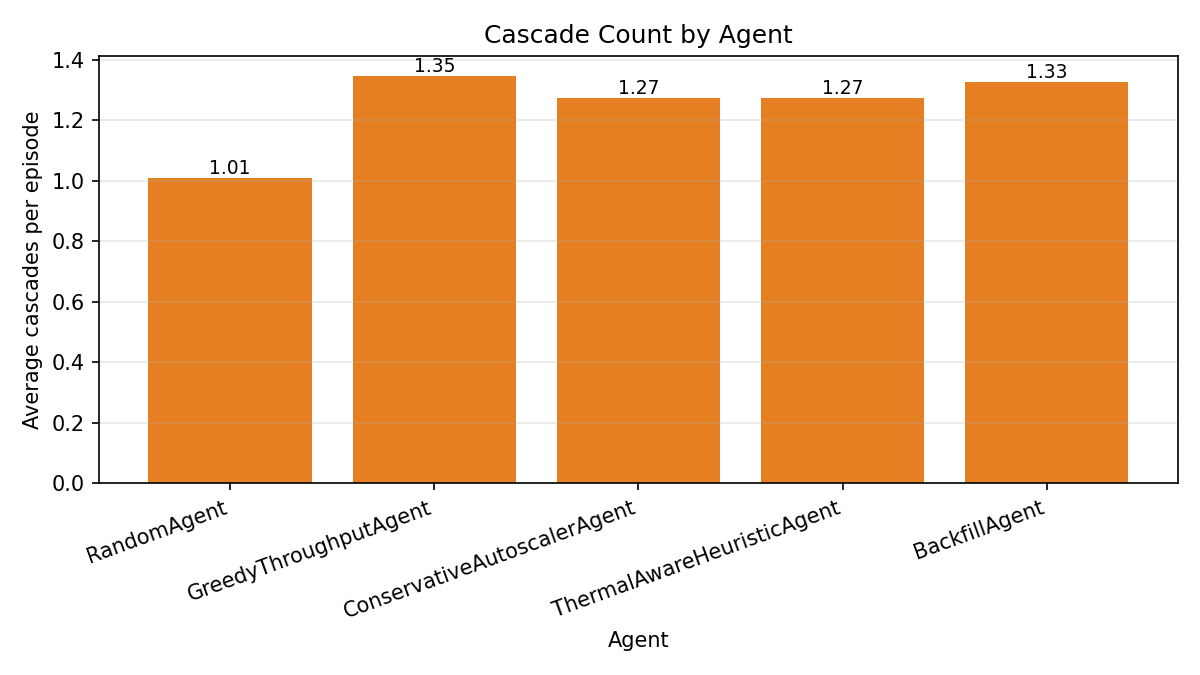

**critical_job_completion.png** — Critical-job completion rate.

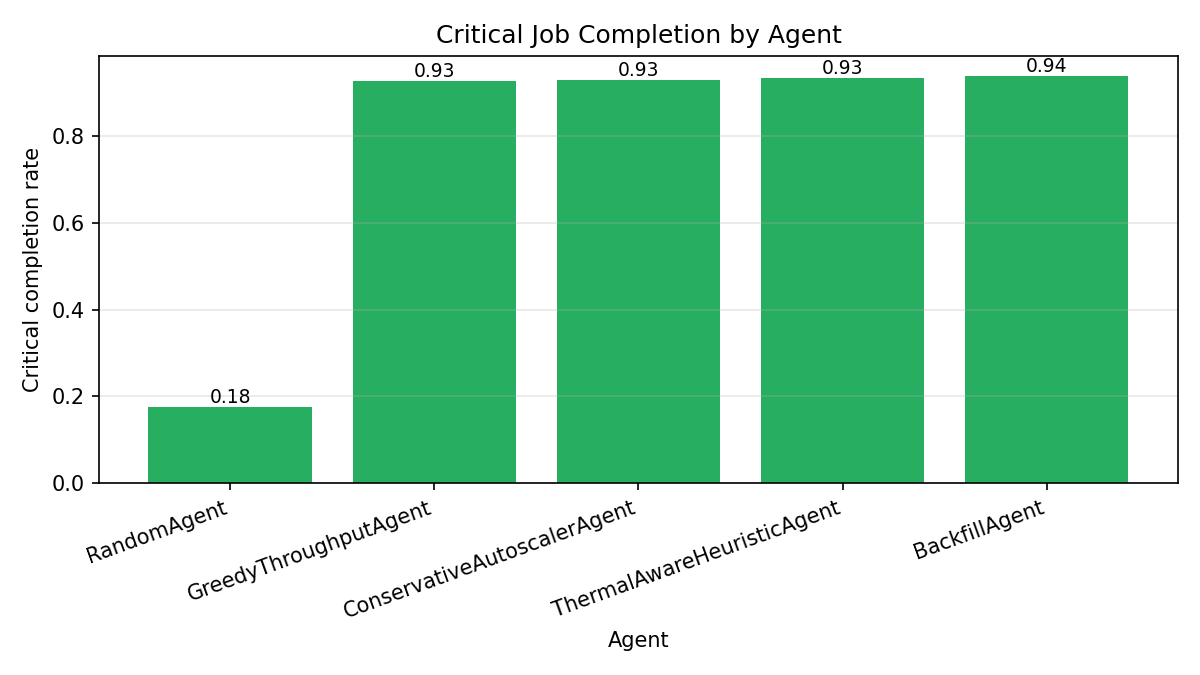

**guardrail_violations.png** — Guardrail-violation rate.

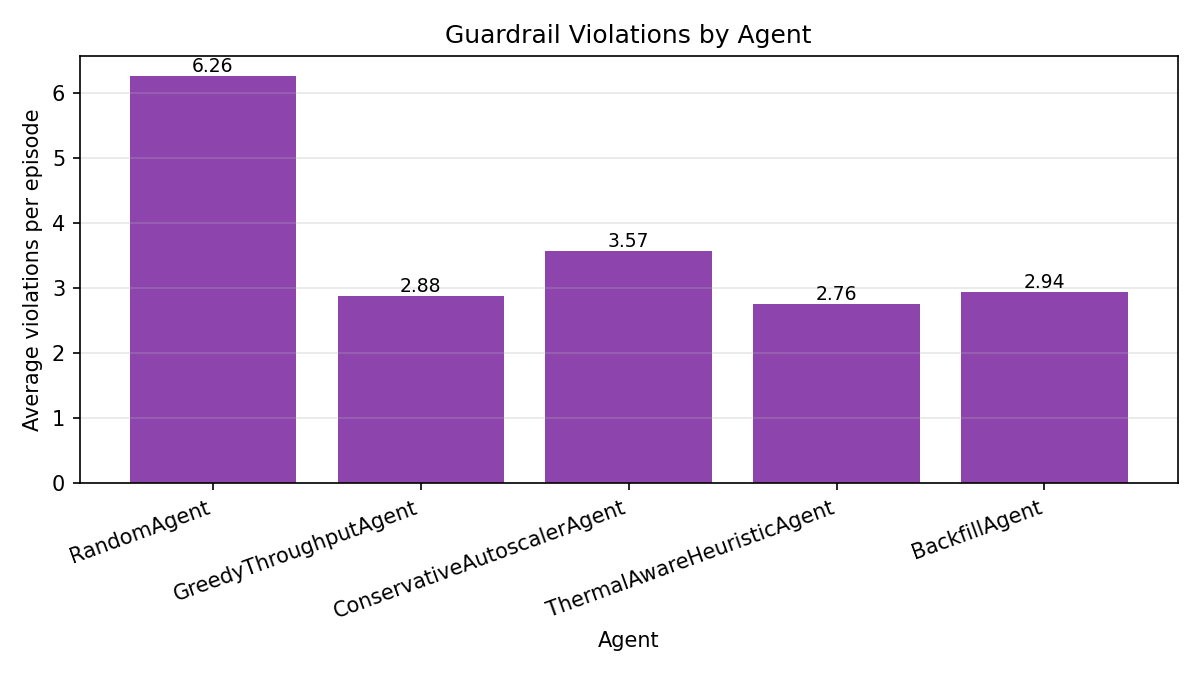

**chaos_survival_score.png** — Chaos-survival proxy (reward x crit completion).

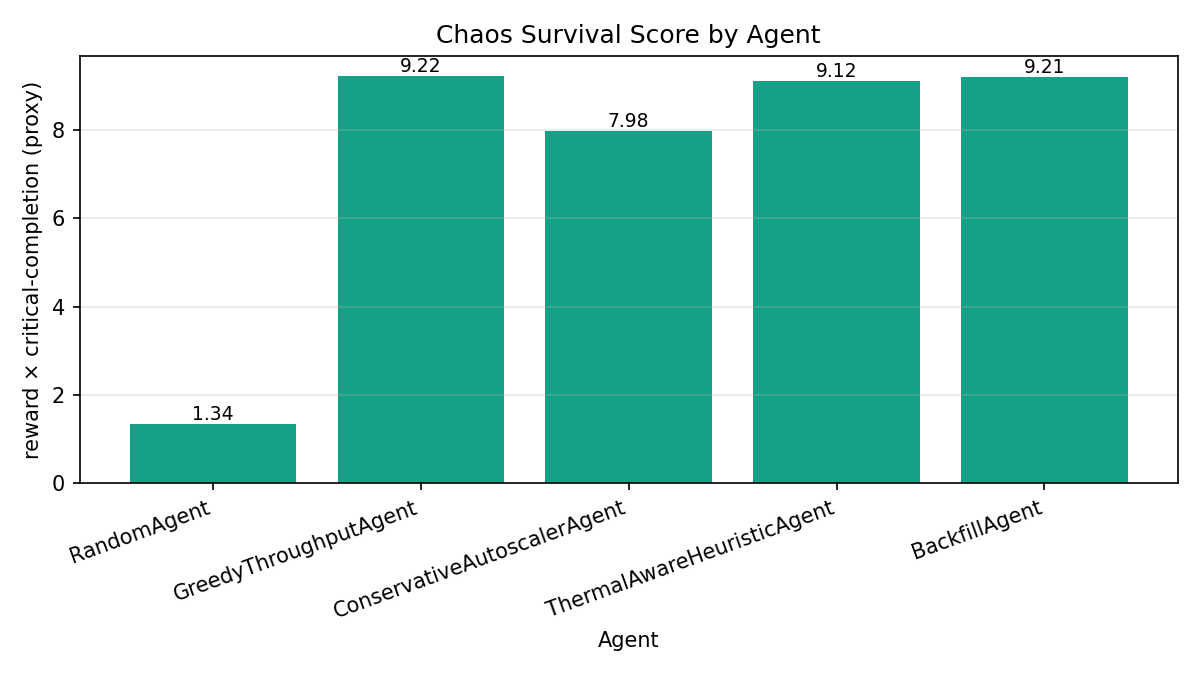

**cluster_health_curve.png** — Cluster health rolling mean during training.

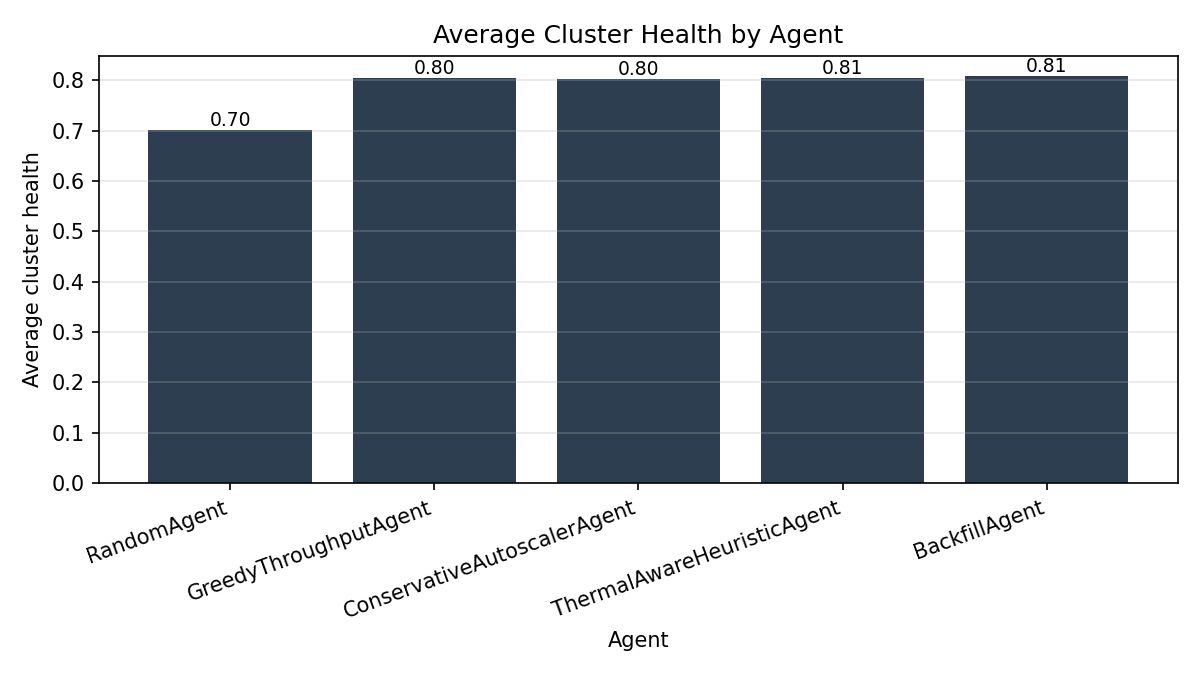

In [113]:
from IPython.display import Image, display, Markdown
captions = {
    'reward_curve.png': 'Per-episode RL reward across live env rollouts.',
    'loss_curve.png': 'SFT cross-entropy + RL policy loss.',
    'outage_comparison.png': 'Average outages per episode by agent.',
    'cascade_count_comparison.png': 'Linked-failure cascades per agent.',
    'critical_job_completion.png': 'Critical-job completion rate.',
    'guardrail_violations.png': 'Guardrail-violation rate.',
    'chaos_survival_score.png': 'Chaos-survival proxy (reward x crit completion).',
    'cluster_health_curve.png': 'Cluster health rolling mean during training.',
}
for name, cap in captions.items():
    display(Markdown(f'**{name}** — {cap}'))
    display(Image(filename=f'results/{name}'))

## 10 — Flight Recorder narrative for the storytelling demo

In [114]:
!python scripts/export_replay.py --agent GreedyThroughputAgent --scenario triple_crisis --level 4 --seed 7

wrote /content/clustermind-chaos-arena/results/replays/GreedyThroughputAgent__triple_crisis__L4__seed7.json
wrote /content/clustermind-chaos-arena/results/replays/GreedyThroughputAgent__triple_crisis__L4__seed7__failure_chain.txt

--- failure chain ---
Step  1: agent=ALLOCATE_JOB  chaos=—  events=allocate:job_1->gpu_2; node_failed:gpu_0; node_failed:gpu_3; node_failed:gpu_9 — failures: gpu_0, gpu_3, gpu_9 | cascade: shock:gpu_0->gpu_4,gpu_1, shock:gpu_3->gpu_2,gpu_4, shock:gpu_9->gpu_8,gpu_5
Step  2: agent=ALLOCATE_JOB  chaos=—  events=allocate:job_4->gpu_7; node_failed:gpu_4 — failures: gpu_4 | cascade: linked:gpu_4@step2
Step  3: agent=ALLOCATE_JOB  chaos=—  events=allocate:job_0->gpu_6
Step  4: agent=ALLOCATE_JOB  chaos=—  events=allocate:job_2->gpu_5


## 11 — Trained-agent demo loop (LoRA path only)

In [115]:
import os
if os.path.isdir('results/adapters/clustermind_lora'):
    from clustermind import ClusterMindChaosEnv
    from clustermind.agents import LLMJsonAgent, TransformersBackend
    from clustermind.baselines import ThermalAwareHeuristicAgent
    backend = TransformersBackend(model_name='Qwen/Qwen2.5-0.5B-Instruct',
                                  adapter_path='results/adapters/clustermind_lora')
    agent = LLMJsonAgent(backend=backend, fallback_baseline=ThermalAwareHeuristicAgent(), label='RL-LoRA')
    env = ClusterMindChaosEnv()
    obs = env.reset(seed=99, options={'scenario': 'chaos_arena', 'curriculum_level': 5, 'max_steps': 18})
    total = 0.0
    while not obs.done:
        action = agent.act(obs)
        obs, r, done, info = env.step(action)
        total += r
        chaos = info.get('chaos_action') or '-'
        print(f"step {obs.step:>2}: {action.action_type.value:18s} chaos={chaos:25s} reward={r:+.3f} health={obs.cluster_health:.2f}")
    print(f"\ntotal reward: {total:.2f}\nparse stats: {agent.stats()}")
else:
    print('Skipping — LoRA adapter not present (Step 7 ran the policy-net path).')

Skipping — LoRA adapter not present (Step 7 ran the policy-net path).


## 12 — Final summary table

In [116]:
import json, os
print('=' * 90)
print('FINAL SUMMARY')
print('=' * 90)
if os.path.isfile('results/trained_results.json'):
    with open('results/trained_results.json') as f: tr = json.load(f)
    print(f"Training schema:   {tr.get('schema')}")
    print(f"RL algo used:      {tr.get('rl_algo')}  ({tr.get('rl_algo_note', '')})")
    print(f"Frozen base:       {tr.get('frozen_base')}")
    print(f"LoRA-only updates: {tr.get('lora_only')}")
    if tr.get('eval_mean_reward') is not None:
        print(f"Trained-agent eval mean reward: {tr['eval_mean_reward']:.2f}")
if os.path.isfile('results/evaluation_metrics.json'):
    with open('results/evaluation_metrics.json') as f: ev = json.load(f)
    print()
    print(f"{'agent':25s} {'reward':>7s} {'crit%':>6s} {'outage':>7s} {'cascade':>8s} {'grade':>6s}")
    for name, blob in ev['agents'].items():
        s = blob['summary']
        band = blob.get('overall_band', '-')
        print(f"{name:25s} {s.get('avg_reward', 0):7.2f} {s.get('critical_completion_rate', 0)*100:5.1f}%"
              f" {s.get('avg_outage_count', 0):7.2f} {s.get('avg_cascade_count', 0):8.2f} {band:>6s}")

FINAL SUMMARY
Training schema:   clustermind.training.policy_net.v1
RL algo used:      reinforce  (policy-net path uses REINFORCE with moving baseline (no LLM stack present))
Frozen base:       False
LoRA-only updates: False
Trained-agent eval mean reward: 12.84

agent                      reward  crit%  outage  cascade  grade
RandomAgent                  7.62  17.6%    3.01     1.01      F
GreedyThroughputAgent        9.93  92.8%    3.53     1.35      C
ConservativeAutoscalerAgent    8.58  93.0%    3.52     1.27      C
ThermalAwareHeuristicAgent    9.76  93.5%    3.45     1.27      C
BackfillAgent                9.81  93.8%    3.44     1.33      C


## Done
Artifacts to commit / upload to the HF Space:
- `results/adapters/clustermind_lora/` — trained LoRA adapter (frozen base, LoRA only)
- `results/training_logs.jsonl` — per-episode reward + loss + algo
- `results/trained_results.json` — final summary with `rl_algo`, `frozen_base`, `lora_only`
- `results/*.png` — the eight required plots
- `results/replays/*.json` — Flight Recorder rollouts

**Honest disclosure:** if Step 7 ran the policy-net plumbing path (no transformers/peft), the schema in `trained_results.json` will be `clustermind.training.policy_net.v1` — that proves the pipeline runs but is *not* an LLM/LoRA result. To get LLM/LoRA evidence, run this notebook on Colab where transformers + peft are installed.